In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/AllCleaned.csv')
df.head()

,DateTime,Hour,DayOfWeek,WeekOfYear,Month,IsHoliday,IsWeekend,IsWeekendOrHoliday,DayNight_Night,pm2_5,temp,dew_point,relative_humidity,wind_speed,pressure,precipitation,no2,so2,o3
0,1/1/2023 0:30,0,6,52,1,0,1,1,1,34.0,25.3,20.8,76,3.7,1014.4,0.0,7.12,13.420000,2.16
1,1/1/2023 1:30,1,6,52,1,0,1,1,1,43.0,25.0,20.3,75,3.7,1013.9,0.0,8.56,15.000000,1.93
2,1/1/2023 2:30,2,6,52,1,0,1,1,1,51.0,24.6,19.9,75,3.7,1013.3,0.0,7.11,14.840000,2.47
3,1/1/2023 3:30,3,6,52,1,0,1,1,1,40.0,23.5,20.2,82,3.7,1013.4,0.0,9.45,16.170000,3.74
4,1/1/2023 4:30,4,6,52,1,0,1,1,1,41.0,23.0,20.1,84,3.7,1013.6,0.0,27.07,6.507762,2.66


In [ ]:
df.set_index('DateTime', inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21065 entries, 1/1/2023 0:30 to 5/27/2025 16:30
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Hour                21065 non-null  int64  
 1   DayOfWeek           21065 non-null  int64  
 2   WeekOfYear          21065 non-null  int64  
 3   Month               21065 non-null  int64  
 4   IsHoliday           21065 non-null  int64  
 5   IsWeekend           21065 non-null  int64  
 6   IsWeekendOrHoliday  21065 non-null  int64  
 7   DayNight_Night      21065 non-null  int64  
 8   pm2_5               21065 non-null  float64
 9   temp                21065 non-null  float64
 10  dew_point           21065 non-null  float64
 11  relative_humidity   21065 non-null  int64  
 12  wind_speed          21065 non-null  float64
 13  pressure            21065 non-null  float64
 14  precipitation       21065 non-null  float64
 15  no2                 21065 non-null  

In [ ]:
df_imputed = df.copy()

In [ ]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21065 entries, 1/1/2023 0:30 to 5/27/2025 16:30
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Hour                21065 non-null  int64  
 1   DayOfWeek           21065 non-null  int64  
 2   WeekOfYear          21065 non-null  int64  
 3   Month               21065 non-null  int64  
 4   IsHoliday           21065 non-null  int64  
 5   IsWeekend           21065 non-null  int64  
 6   IsWeekendOrHoliday  21065 non-null  int64  
 7   DayNight_Night      21065 non-null  int64  
 8   pm2_5               21065 non-null  float64
 9   temp                21065 non-null  float64
 10  dew_point           21065 non-null  float64
 11  relative_humidity   21065 non-null  int64  
 12  wind_speed          21065 non-null  float64
 13  pressure            21065 non-null  float64
 14  precipitation       21065 non-null  float64
 15  no2                 21065 non-null  

In [ ]:
df_imputed['Rolling_mean_24'] = df['pm2_5'].rolling(window=24).mean().shift(1)
df_imputed['Rolling_std_24'] = df['pm2_5'].rolling(window=24).std().shift(1)

df_imputed['Rolling_mean_week'] = df['pm2_5'].rolling(window=168).mean().shift(1)
df_imputed['Rolling_std_week'] = df['pm2_5'].rolling(window=168).std().shift(1)
df_imputed['pm2_5_lag_1'] = df['pm2_5'].shift(1)
df_imputed['pm2_5_lag_2'] = df['pm2_5'].shift(2)
df_imputed['pm2_5_lag_3'] = df['pm2_5'].shift(3)
df_imputed['pm2_5_lag_4'] = df['pm2_5'].shift(4)
df_imputed['pm2_5_lag_5'] = df['pm2_5'].shift(5)
df_imputed['pm2_5_lag_6'] = df['pm2_5'].shift(6)
df_imputed['pm2_5_lag_7'] = df['pm2_5'].shift(7)
df_imputed['pm2_5_lag_8'] = df['pm2_5'].shift(8)
df_imputed['pm2_5_lag_9'] = df['pm2_5'].shift(9)
df_imputed['pm2_5_lag_10'] = df['pm2_5'].shift(10)
df_imputed['pm2_5_lag_11'] = df['pm2_5'].shift(11)
df_imputed['pm2_5_lag_12'] = df['pm2_5'].shift(12)

In [ ]:
df_filtered = df_imputed.iloc[168:]
print("Dropped the first 168 rows from the DataFrame.")
display(df_filtered.head())

Dropped the first 168 rows from the DataFrame.


,Hour,DayOfWeek,WeekOfYear,Month,IsHoliday,IsWeekend,IsWeekendOrHoliday,DayNight_Night,pm2_5,temp,...,pm2_5_lag_3,pm2_5_lag_4,pm2_5_lag_5,pm2_5_lag_6,pm2_5_lag_7,pm2_5_lag_8,pm2_5_lag_9,pm2_5_lag_10,pm2_5_lag_11,pm2_5_lag_12
DateTime,,,,,,,,,,,,,,,,,,,,,
1/8/2023 0:30,0,6,1,1,0,1,1,1,26.0,24.7,...,12.0,13.0,12.0,16.0,15.0,14.0,13.0,4.0,38.970404,40.136371
1/8/2023 1:30,1,6,1,1,0,1,1,1,27.0,24.6,...,13.0,12.0,13.0,12.0,16.0,15.0,14.0,13.0,4.000000,38.970404
1/8/2023 2:30,2,6,1,1,0,1,1,1,43.0,24.5,...,18.0,13.0,12.0,13.0,12.0,16.0,15.0,14.0,13.000000,4.000000
1/8/2023 3:30,3,6,1,1,0,1,1,1,23.0,23.9,...,26.0,18.0,13.0,12.0,13.0,12.0,16.0,15.0,14.000000,13.000000
1/8/2023 4:30,4,6,1,1,0,1,1,1,25.0,23.8,...,27.0,26.0,18.0,13.0,12.0,13.0,12.0,16.0,15.000000,14.000000


In [ ]:
df_filtered.isnull().sum()

,0
Hour,0
DayOfWeek,0
WeekOfYear,0
Month,0
IsHoliday,0
IsWeekend,0
IsWeekendOrHoliday,0
DayNight_Night,0
pm2_5,0
temp,0


<Axes: >

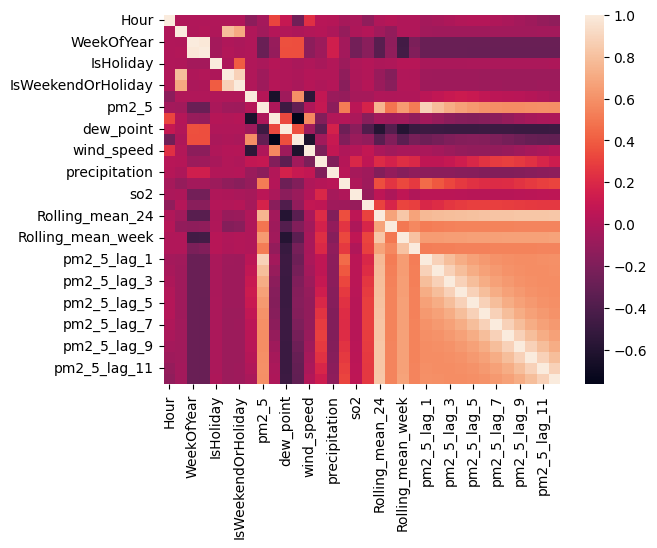

In [ ]:
sns.heatmap(df_filtered.corr())

In [ ]:
df_filtered.index = pd.DatetimeIndex(df_filtered.index)
df_filtered.head()

,Hour,DayOfWeek,WeekOfYear,Month,IsHoliday,IsWeekend,IsWeekendOrHoliday,DayNight_Night,pm2_5,temp,...,pm2_5_lag_3,pm2_5_lag_4,pm2_5_lag_5,pm2_5_lag_6,pm2_5_lag_7,pm2_5_lag_8,pm2_5_lag_9,pm2_5_lag_10,pm2_5_lag_11,pm2_5_lag_12
DateTime,,,,,,,,,,,,,,,,,,,,,
2023-01-08 00:30:00,0,6,1,1,0,1,1,1,26.0,24.7,...,12.0,13.0,12.0,16.0,15.0,14.0,13.0,4.0,38.970404,40.136371
2023-01-08 01:30:00,1,6,1,1,0,1,1,1,27.0,24.6,...,13.0,12.0,13.0,12.0,16.0,15.0,14.0,13.0,4.000000,38.970404
2023-01-08 02:30:00,2,6,1,1,0,1,1,1,43.0,24.5,...,18.0,13.0,12.0,13.0,12.0,16.0,15.0,14.0,13.000000,4.000000
2023-01-08 03:30:00,3,6,1,1,0,1,1,1,23.0,23.9,...,26.0,18.0,13.0,12.0,13.0,12.0,16.0,15.0,14.000000,13.000000
2023-01-08 04:30:00,4,6,1,1,0,1,1,1,25.0,23.8,...,27.0,26.0,18.0,13.0,12.0,13.0,12.0,16.0,15.000000,14.000000


/tmp/ipython-input-4162196173.py:5: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  last_two_days_df = df_filtered.last('7D')


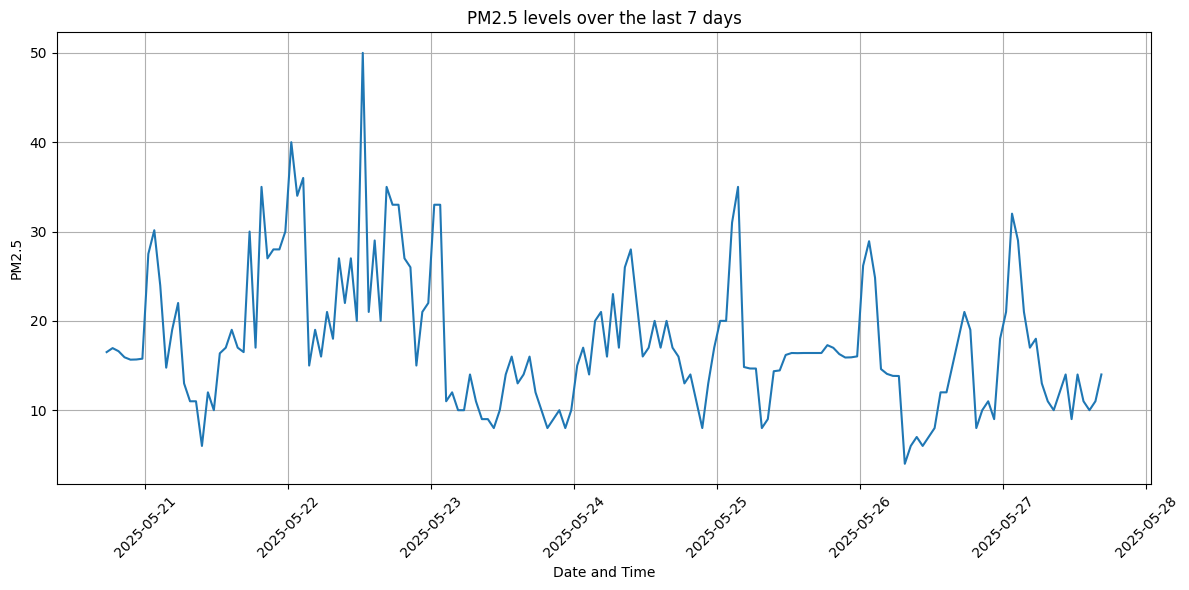

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the last two days of data
last_two_days_df = df_filtered.last('7D')

# Create the plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=last_two_days_df.index, y=last_two_days_df['pm2_5'])
plt.title('PM2.5 levels over the last 7 days')
plt.xlabel('Date and Time')
plt.ylabel('PM2.5')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21065 entries, 1/1/2023 0:30 to 5/27/2025 16:30
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Hour                21065 non-null  int64  
 1   DayOfWeek           21065 non-null  int64  
 2   WeekOfYear          21065 non-null  int64  
 3   Month               21065 non-null  int64  
 4   IsHoliday           21065 non-null  int64  
 5   IsWeekend           21065 non-null  int64  
 6   IsWeekendOrHoliday  21065 non-null  int64  
 7   DayNight_Night      21065 non-null  int64  
 8   pm2_5               21065 non-null  float64
 9   temp                21065 non-null  float64
 10  dew_point           21065 non-null  float64
 11  relative_humidity   21065 non-null  int64  
 12  wind_speed          21065 non-null  float64
 13  pressure            21065 non-null  float64
 14  precipitation       21065 non-null  float64
 15  no2                 21065 non-null  

In [ ]:
!pip install darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.1/75.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3

In [ ]:
from darts import TimeSeries

splitRatio = round(len(df_filtered)*0.8)
y = TimeSeries.from_series(df_filtered['pm2_5'])
y_train = y[:splitRatio]
y_test = y[splitRatio:]

future_features = ['Hour','DayOfWeek','WeekOfYear','Month','IsWeekendOrHoliday','DayNight_Night']
future_cov = TimeSeries.from_dataframe(df_filtered[future_features])

past_features = ['temp','dew_point','relative_humidity','wind_speed','pressure','precipitation','Rolling_mean_24','Rolling_std_24','Rolling_mean_week','Rolling_std_week','o3','no2','so2']
past_cov = TimeSeries.from_dataframe(df_filtered[past_features])

In [ ]:
y_train2 = y[:-72]
y_test2 = y[-72:]

In [ ]:
from darts.models import LinearRegressionModel
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from darts.metrics import r2_score

modelLR = LinearRegressionModel(
    lags=12,
    lags_future_covariates=[0],
    lags_past_covariates=[-1],
    output_chunk_length=1,
)

modelLR.fit(y_train, future_covariates=future_cov,past_covariates=past_cov)

y_pred = modelLR.predict(
    n=len(y_test),
    series=y_train,
    future_covariates=future_cov,
    past_covariates=past_cov
    )

In [ ]:
def evaluate_forecasts(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    mape = mean_absolute_percentage_error(actual, predicted)

    print('MSE: %.3f' % mse)
    print('MAE: %.3f' % mae)
    print('MAPE: %.3f' % mape)



In [ ]:
evaluate_forecasts(actual=y_test.values(), predicted=y_pred.values())

MSE: 178.198
MAE: 9.502
MAPE: 0.334


In [ ]:
print(r2_score(y_test, y_pred))

0.3741249272193421


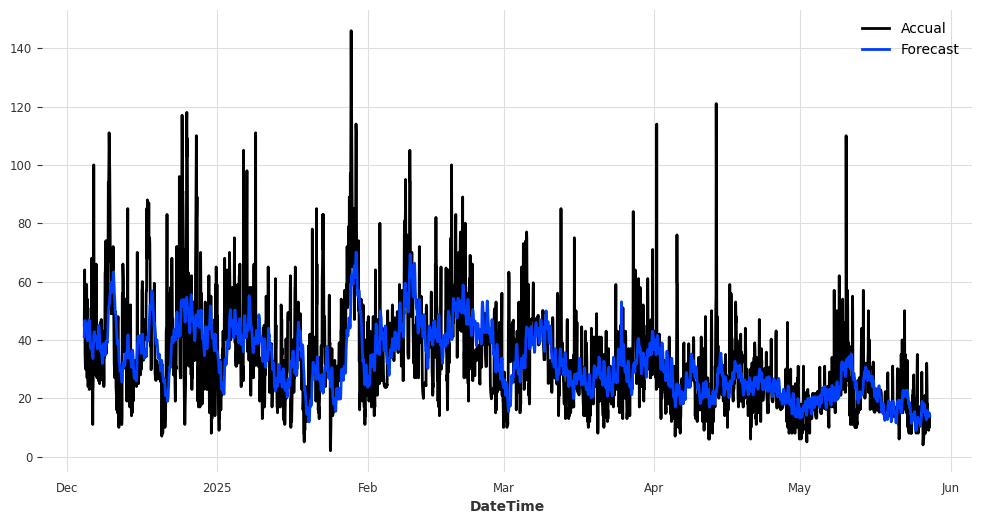

In [ ]:
plt.figure(figsize=(12, 6))
y_test.plot(label='Accual')
y_pred.plot(label='Forecast')
plt.legend()
plt.show()

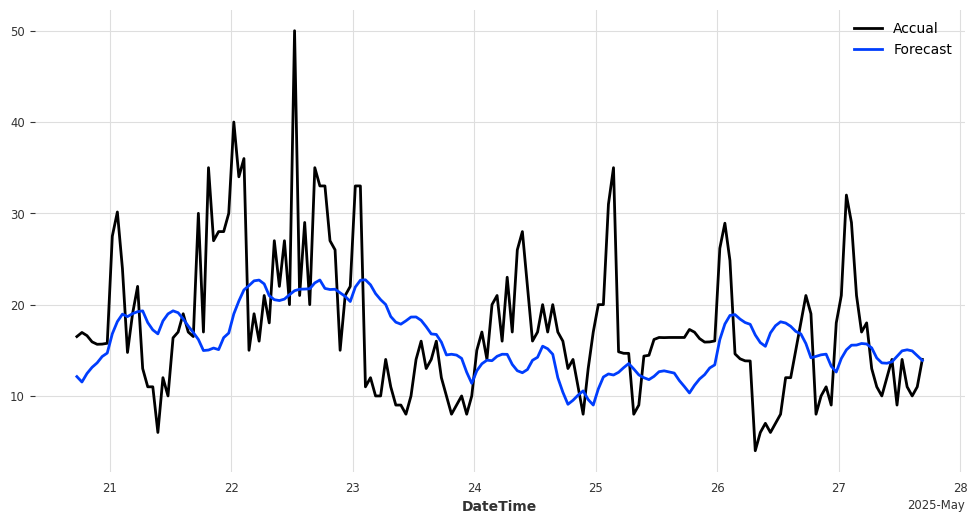

In [ ]:
plt.figure(figsize=(12, 6))
y_test[-168:].plot(label='Accual')
y_pred[-168:].plot(label='Forecast')
plt.legend()
plt.show()

In [ ]:
resLR = modelLR.residuals(
    series=y_train,
    future_covariates=future_cov,
    past_covariates=past_cov
)

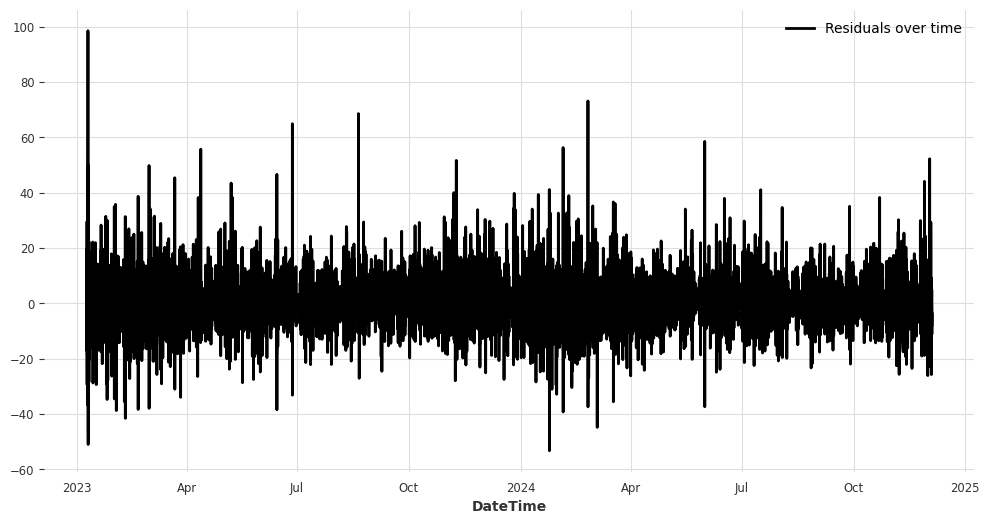

In [ ]:
plt.figure(figsize=(12, 6))
resLR.plot(label='Residuals over time')
plt.legend()
plt.show()

## Random Forest

In [ ]:
from darts.models import RandomForest

modelRF = RandomForest(
    lags=3,
    lags_past_covariates=[-1],
    lags_future_covariates=[0],
    output_chunk_length=1,
    n_estimators=100,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=3,
    criterion="absolute_error",
)
modelRF.fit(y_train, past_covariates=past_cov, future_covariates=future_cov)
predRF = modelRF.predict(72)

KeyboardInterrupt: 

In [ ]:
evaluate_forecasts(actual=y_test[:72].values(), predicted=predRF.values())

MSE: 224.534
MAE: 11.015
MAPE: 0.292


In [ ]:
plt.figure(figsize=(12, 6))
y_test[:72].plot(label='Accual')
predRF.plot(label='Forecast')
plt.legend()
plt.show()

NameError: name 'plt' is not defined

XGBoost

In [ ]:
from darts.models import XGBModel
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from darts.metrics import r2_score

modelXG = XGBModel(
    lags=12,
    lags_future_covariates=[0],
    lags_past_covariates=1,
    output_chunk_length=1,
)

modelXG.fit(y_train, future_covariates=future_cov,past_covariates=past_cov)

y_predXG = modelXG.predict(
    n=len(y_test),
    series=y_train,
    future_covariates=future_cov,
    past_covariates=past_cov
    )

In [ ]:
evaluate_forecasts(actual=y_test.values(), predicted=y_predXG.values())

MSE: 170.107
MAE: 9.303
MAPE: 0.322


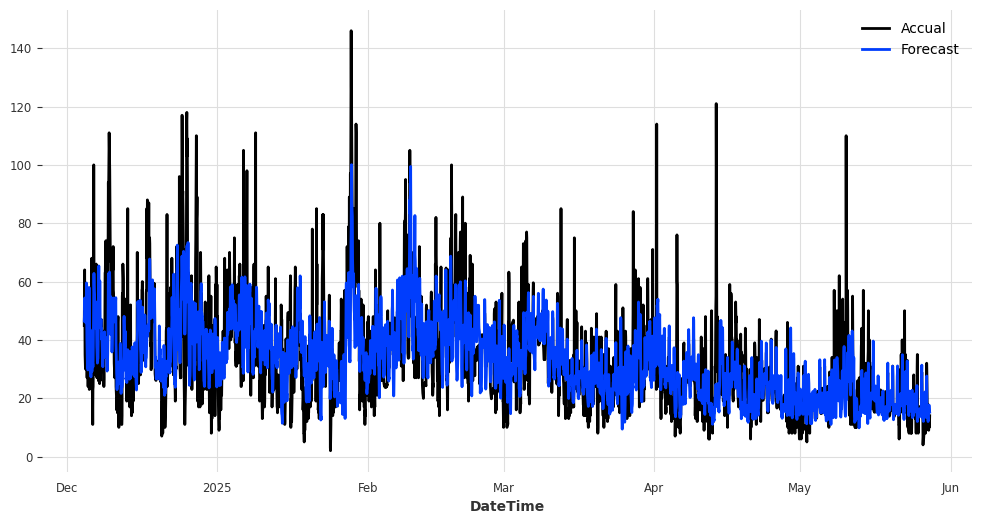

In [ ]:
plt.figure(figsize=(12, 6))
y_test.plot(label='Accual')
y_predXG.plot(label='Forecast')
plt.legend()
plt.show()

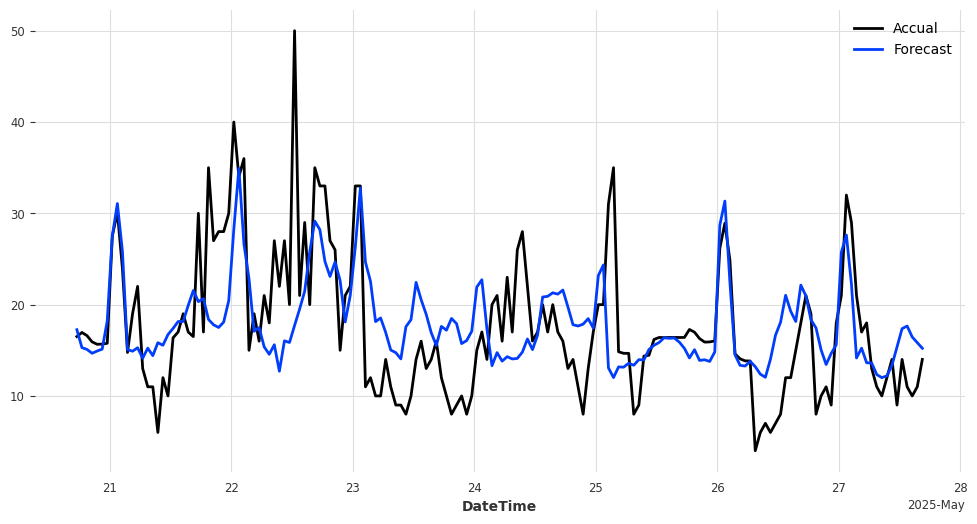

In [ ]:
plt.figure(figsize=(12, 6))
y_test[-168:].plot(label='Accual')
y_predXG[-168:].plot(label='Forecast')
plt.legend()
plt.show()

In [ ]:
print(r2_score(y_test, y_predXG))

0.4025433776096059


## CATBoost

In [ ]:
from darts.models import CatBoostModel

modelCAT = CatBoostModel(
    lags=12,
    lags_future_covariates=[0],
    lags_past_covariates=1,
    output_chunk_length=1,
)

modelCAT.fit(y_train, future_covariates=future_cov,past_covariates=past_cov)

y_predCAT = modelCAT.predict(
    n=len(y_test),
    series=y_train,
    future_covariates=future_cov,
    past_covariates=past_cov
    )

In [ ]:
evaluate_forecasts(actual=y_test.values(), predicted=y_predCAT.values())

MSE: 164.995
MAE: 9.025
MAPE: 0.324


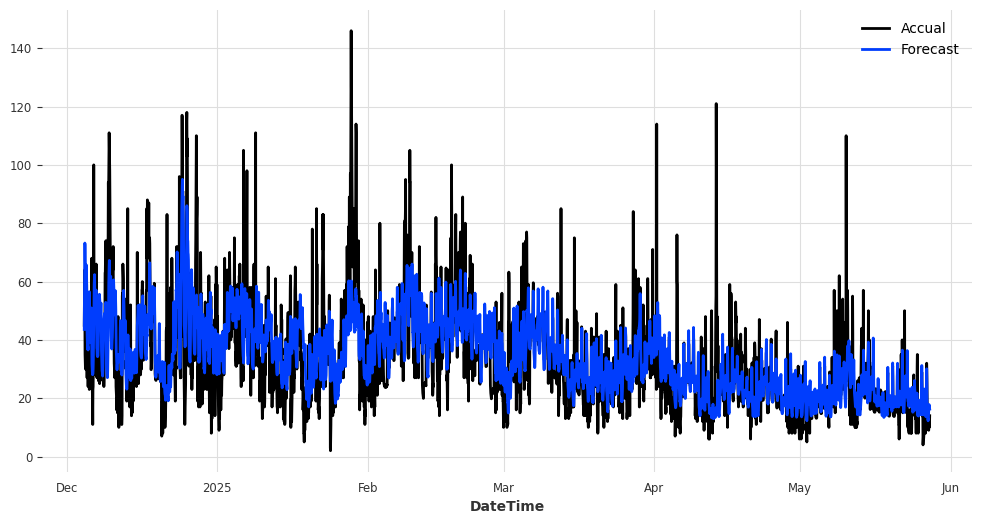

In [ ]:
plt.figure(figsize=(12, 6))
y_test.plot(label='Accual')
y_predCAT.plot(label='Forecast')
plt.legend()
plt.show()

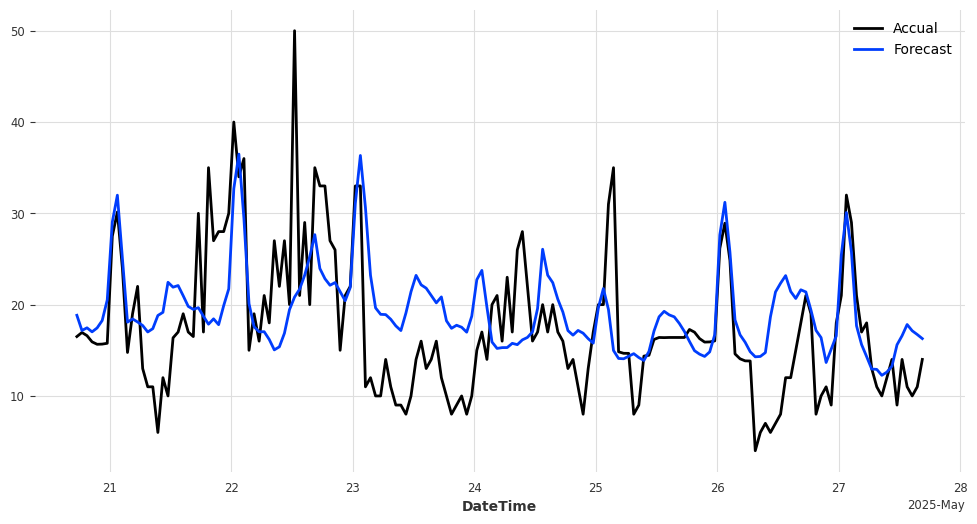

In [ ]:
plt.figure(figsize=(12, 6))
y_test[-168:].plot(label='Accual')
y_predCAT[-168:].plot(label='Forecast')
plt.legend()
plt.show()

In [ ]:
r2_score(y_test,y_predCAT)

np.float64(0.4204994693895199)

## LightGBM

In [ ]:
from darts.models import LightGBMModel

modelLight = LightGBMModel(
    lags=12,
    lags_future_covariates=[0],
    lags_past_covariates=1,
    output_chunk_length=1,
)

modelLight.fit(y_train, future_covariates=future_cov,past_covariates=past_cov)

y_predLight = modelLight.predict(
    n=len(y_test),
    series=y_train,
    future_covariates=future_cov,
    past_covariates=past_cov
    )

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000598 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5412
[LightGBM] [Info] Number of data points in the train set: 16706, number of used features: 31
[LightGBM] [Info] Start training from score 22.152947


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr

In [ ]:
evaluate_forecasts(actual=y_test.values(), predicted=y_predLight.values())

MSE: 176.829
MAE: 9.575
MAPE: 0.360


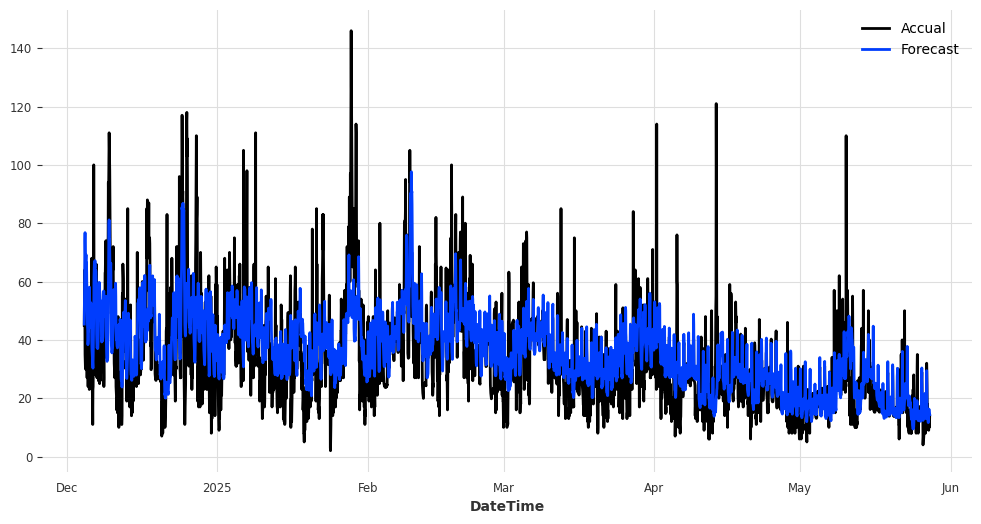

In [ ]:
plt.figure(figsize=(12, 6))
y_test.plot(label='Accual')
y_predLight.plot(label='Forecast')
plt.legend()
plt.show()

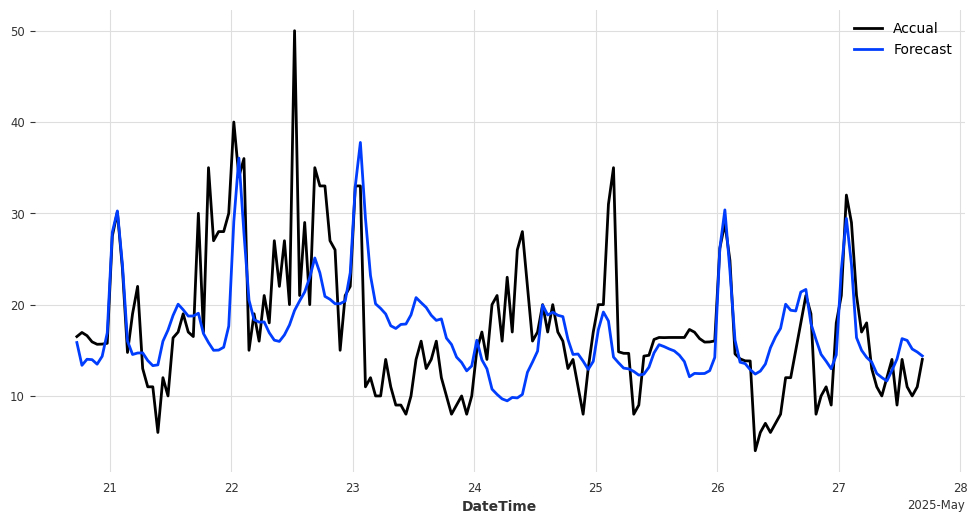

In [ ]:
plt.figure(figsize=(12, 6))
y_test[-168:].plot(label='Accual')
y_predLight[-168:].plot(label='Forecast')
plt.legend()
plt.show()

In [ ]:
r2_score(y_test,y_predLight)

np.float64(0.37893501498631776)